# Music Diffusion Transformer

## Dataset

The [Song Describer Dataset (SDD)](https://zenodo.org/records/10072001) is a multimodal music-language dataset designed for tasks such as music captioning, text-to-music generation, and music-language retrieval. It contains approximately 1,100 human-written natural language captions paired with 706 permissively licensed music recordings, covering a wide range of musical styles, instruments, moods, and production characteristics. The dataset was introduced by researchers from institutions including Queen Mary University of London and Universitat Pompeu Fabra as a public benchmark for evaluating music-and-language models. Unlike many proprietary music datasets, SDD emphasizes open accessibility and standardized evaluation for cross-modal learning research. It is particularly suitable for training and benchmarking Transformer-, diffusion-, and CLAP-based architectures for text-conditioned music generation and retrieval tasks

In [1]:
from torch.utils.data import Dataset
import pandas as pd
import numpy as np
import librosa
import torch
import os


class AudioDataset(Dataset):
    def __init__(self, csv_path="./dataset/song_describer.csv", audio_dir="./dataset/audio/"):
        self.df = pd.read_csv(csv_path)
        self.audio_dir = audio_dir
        self.SAMPLE_RATE = 22050
        self.N_MELS = 80
        self.N_FFT = 1024
        self.HOP_LENGTH = 256
        self.WIN_LENGTH = 1024
        self.max_len = self.SAMPLE_RATE * 10
        self.generate_file_map()

    def __len__(self):
        return len(self.df)

    def generate_file_map(self):
        self.file_map = {}

        for root, dirs, files in os.walk(self.audio_dir):
            for f in files:
                if f.endswith(".mp3"):
                    track_id = f.split(".")[0]
                    self.file_map[track_id] = os.path.join(root, f)
    
    def load_audio(self, path, target_sr=22050):
        wav, sr = librosa.load(path, sr=target_sr, mono=True)

        if len(wav) > self.max_len:
            wav = wav[:self.max_len]
        else:
            wav = np.pad(wav, (0, self.max_len - len(wav)))
        return wav

    def audio_to_mel(self, audio_path):
        wav = self.load_audio(audio_path, self.SAMPLE_RATE)
        mel = librosa.feature.melspectrogram(
            y=wav,
            sr=self.SAMPLE_RATE,
            n_fft=self.N_FFT,
            hop_length=self.HOP_LENGTH,
            n_mels=self.N_MELS,
            power=2.0
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)
        return torch.tensor(mel_db, dtype=torch.float32).unsqueeze(0)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        caption = row["caption"]
        track_id = str(row["track_id"])

        mel_spectrum = self.audio_to_mel(self.file_map[track_id])
        return mel_spectrum, caption

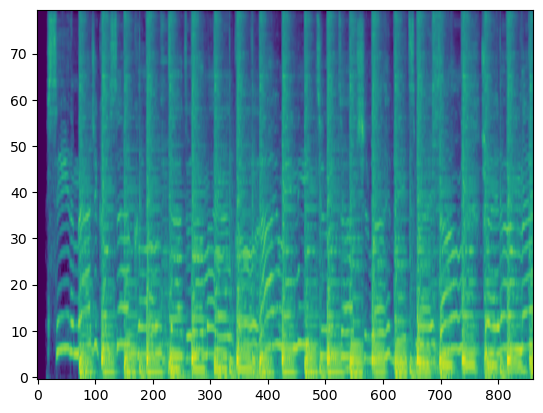

In [2]:
import matplotlib.pyplot as plt

audio_dataset = AudioDataset()

mel_np = audio_dataset[3][0].squeeze(0).detach().cpu().numpy()
plt.imshow(mel_np, origin="lower", aspect="auto")

## Model Architectures

### CLAP Text Encoder

The CLAP Text Encoder is used to convert a natural language music prompt into a fixed-dimensional conditioning embedding. It uses a pretrained CLAP model, which has learned an aligned representation space between text and audio. Given an input caption, the processor first tokenizes the text and creates the attention mask, then the CLAP text encoder extracts a semantic text feature. This feature is L2-normalized and passed through a projection layer so that its dimension matches the diffusion model’s conditioning input. During training, the CLAP model is frozen, and only the downstream diffusion model learns how to use the text embedding to guide mel-spectrogram generation.

In [5]:
from transformers import ClapModel, ClapProcessor
import torch
import torch.nn as nn

class CLAPTextEncoder(nn.Module):
    def __init__(self, model_name="laion/clap-htsat-fused", out_dim=512):
        super().__init__()

        self.processor = ClapProcessor.from_pretrained(model_name)
        self.clap = ClapModel.from_pretrained(model_name)

        for p in self.clap.parameters():
            p.requires_grad = False

        self.proj = nn.Linear(512, out_dim)

    def forward(self, prompts):
        device = next(self.clap.parameters()).device

        inputs = self.processor(
            text=prompts,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(device)

        with torch.no_grad():
            outputs = self.clap.get_text_features(**inputs)
            text_emb = outputs
        
        text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True)
        return self.proj(text_emb)

In [6]:
text_encoder = CLAPTextEncoder(out_dim=512).cuda()

prompts = [
    "playful cartoon comedy music",
    "chaotic banana-themed soundtrack"
]

cond = text_encoder(prompts)
print(cond.shape)

torch.Size([2, 512])


In [14]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    mels = torch.stack([item[0] for item in batch])  # (B, 1, 80, T)
    captions = [item[1] for item in batch]
    return mels, captions

train_loader = DataLoader(
    audio_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn,
    drop_last=True,
)

# sanity check
mels, captions = next(iter(train_loader))
print("Mel batch:", mels.shape)         # expect (4, 1, 80, 862)
print("Caption[0]:", captions[0])

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Mel batch: torch.Size([4, 1, 80, 862])
Caption[0]: A lively, uplifting pop track featuring a male vocalist who sings parts of the song in his head voice, accompanied by an intro of piano and occasional appearances by a female vocalist, all supported by a driving, energetic beat that makes it perfect for getting your energy up and lifting your mood, whether you're dancing along or just enjoying the catchy, upbeat vibe.


In [15]:
import torch.nn.functional as F

def pad_mel(mel, target_t=1024):
    """Right-pad time axis. Works for (B, 1, n_mels, T) or (1, n_mels, T)."""
    pad_amount = target_t - mel.size(-1)
    return F.pad(mel, (0, pad_amount))

# also a normalization helper (mel is in dB, roughly [-80, 0])
def normalize_mel(mel):   return (mel + 40.0) / 40.0   # → roughly [-1, 1]
def denormalize_mel(mel): return mel * 40.0 - 40.0     # → back to dB

print(pad_mel(mels).shape)  # expect (4, 1, 80, 1024)

torch.Size([4, 1, 80, 1024])


In [16]:
import torch.nn.functional as F

class GaussianDiffusion:
    def __init__(self, n_steps=1000, beta_start=1e-4, beta_end=0.02, device="cuda"):
        self.n_steps = n_steps
        self.device = device
        self.betas = torch.linspace(beta_start, beta_end, n_steps, device=device)
        self.alphas = 1.0 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)

    def q_sample(self, x0, t, noise):
        """Forward diffusion: add noise to clean x0 at timestep t."""
        a_bar = self.alpha_bars[t].view(-1, 1, 1, 1)
        return torch.sqrt(a_bar) * x0 + torch.sqrt(1 - a_bar) * noise

    def training_loss(self, model, x0, cond):
        b = x0.size(0)
        t = torch.randint(0, self.n_steps, (b,), device=x0.device)
        noise = torch.randn_like(x0)
        x_noisy = self.q_sample(x0, t, noise)
        # diffusers UNet returns an object with .sample
        pred_noise = model(x_noisy, t, encoder_hidden_states=cond).sample
        return F.mse_loss(pred_noise, noise)

    @torch.no_grad()
    def sample(self, model, cond, mel_shape):
        """Reverse diffusion: pure noise → clean mel."""
        x = torch.randn(mel_shape, device=self.device)
        for t in reversed(range(self.n_steps)):
            t_batch = torch.full((x.size(0),), t, device=self.device, dtype=torch.long)
            pred_noise = model(x, t_batch, encoder_hidden_states=cond).sample
            alpha = self.alphas[t]; alpha_bar = self.alpha_bars[t]; beta = self.betas[t]
            x = (1 / torch.sqrt(alpha)) * (x - (beta / torch.sqrt(1 - alpha_bar)) * pred_noise)
            if t > 0:
                x = x + torch.sqrt(beta) * torch.randn_like(x)
        return x

In [1]:
import huggingface_hub
print(huggingface_hub.__version__)   # should be 0.27.x – 0.34.x
from huggingface_hub import DDUFEntry  # should not raise
from diffusers import UNet2DConditionModel
print("OK")

0.34.6


AttributeError: module 'torch' has no attribute 'xpu'

In [22]:
# !pip install diffusers   
from diffusers import UNet2DConditionModel

unet = UNet2DConditionModel(
    sample_size=(80, 1024),
    in_channels=1,
    out_channels=1,
    layers_per_block=2,
    block_out_channels=(64, 128, 256, 256),     # small for pipeline test
    down_block_types=("CrossAttnDownBlock2D", "CrossAttnDownBlock2D",
                      "CrossAttnDownBlock2D", "DownBlock2D"),
    up_block_types=("UpBlock2D", "CrossAttnUpBlock2D",
                    "CrossAttnUpBlock2D", "CrossAttnUpBlock2D"),
    cross_attention_dim=512,    # matches CLAP output
).cuda()

print(f"U-Net params: {sum(p.numel() for p in unet.parameters())/1e6:.1f}M")

ImportError: cannot import name 'DDUFEntry' from 'huggingface_hub' (/opt/conda/lib/python3.11/site-packages/huggingface_hub/__init__.py)

In [ ]:
diffusion = GaussianDiffusion(n_steps=1000, device="cuda")
optimizer = torch.optim.AdamW(unet.parameters(), lr=1e-4)
text_encoder.eval()

unet.train()
MAX_BATCHES = 5     # tiny — we're just proving the pipeline works
for step, (mel, caption) in enumerate(train_loader):
    if step >= MAX_BATCHES:
        break

    mel = pad_mel(mel.cuda())          # (B, 1, 80, 1024)
    mel = normalize_mel(mel)

    with torch.no_grad():
        cond = text_encoder(caption).unsqueeze(1)   # (B, 1, 512)

    loss = diffusion.training_loss(unet, mel, cond)
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(unet.parameters(), 1.0)
    optimizer.step()

    print(f"step {step}: loss = {loss.item():.4f}")

In [ ]:
unet.eval()

test_prompt = ["upbeat acoustic guitar with soft drums"]
with torch.no_grad():
    cond = text_encoder(test_prompt).unsqueeze(1)         # (1, 1, 512)
    generated_mel = diffusion.sample(unet, cond, mel_shape=(1, 1, 80, 1024))

print("Generated mel:", generated_mel.shape)              # (1, 1, 80, 1024)

# visualize
generated_mel_db = denormalize_mel(generated_mel)
plt.figure(figsize=(10, 3))
plt.imshow(generated_mel_db[0, 0].cpu().numpy(), origin="lower", aspect="auto")
plt.title("Generated mel (untrained — will be noise)")
plt.colorbar()
plt.show()

In [ ]:
# pip install speechbrain
from speechbrain.inference.vocoders import HIFIGAN

vocoder = HIFIGAN.from_hparams(
    source="speechbrain/tts-hifigan-ljspeech",
    savedir="pretrained_models/tts-hifigan-ljspeech",
).cuda()
vocoder.eval()
print("HiFi-GAN loaded")